# Chicago Crime Classification using Artificial Neural Networks (ANN)

### Binary Classification: Violent Crime (1) vs Non-Violent Crime (0) **bold text**


## **Project Description**

Public safety agencies across the world use predictive analytics to improve
resource allocation, reduce response time, and identify crime patterns.
Chicago, one of the largest cities in the United States, publishes a detailed
public dataset containing millions of crime records from 2001 to the present.
This dataset includes information about the type of crime, time of occurrence,
location coordinates, arrest details, and multiple contextual attributes.

In this project, our objective is to build an Artificial Neural Network (ANN)
model that predicts whether a crime is *violent* or *non-violent* based on the
details available at the time of reporting. This classification helps law
enforcement agencies understand which incidents require immediate priority and
can also support strategic deployment of patrol units in high-risk areas.

This project is designed as a comprehensive deep learning hands-on exercise
covering data ingestion, data cleaning, feature engineering, normalization,
train–test split, ANN architecture design, loss functions, forward propagation
concepts, backpropagation intuition, hyperparameter tuning, regularization,
early stopping, batch normalization, model evaluation, and business
interpretation of model outcomes.

We will use **5 lakhs rows** sampled from the official Chicago Data Portal
using its public API. The target variable will be defined as:

- **Violent Crime = 1**
- **Non-Violent Crime = 0**

This definition is constructed using the FBI's Uniform Crime Reporting (UCR)
categories, where violent crimes include offenses such as homicide, robbery,
assault, battery, sexual assault, and kidnapping. All other crime types are
considered non-violent for the purpose of this project.

The goal is to create a realistic, industry-level deep learning project that
allows us to apply the full set of neural network concepts learned in the
module while working on a large, high-volume dataset with real operational
significance.


## Data Dictionary

The Chicago Crime dataset contains detailed information about each reported
crime. The key columns relevant for our model are:

- **primary_type**  
  High-level category of the crime (e.g., THEFT, ASSAULT, ROBBERY).  
  This is the basis for constructing our target variable.

- **description**  
  Detailed description of the crime subtype. Helps refine violent crime
  definitions.

- **location_description**  
  Describes where the incident occurred (street, residence, apartment, etc.).
  Useful for understanding environment patterns.

- **domestic**  
  Indicates whether the incident involved people with a domestic relationship.
  Domestically motivated incidents often have different dynamics.

- **arrest**  
  Indicates whether police made an arrest at the time of reporting. This is
  not our target but can act as a predictive feature.

- **year, month, day, hour**  
  Extracted from the timestamp. Helps in finding temporal crime trends.

- **latitude, longitude**  
  Geographical location of the incident. Important for spatial modeling and
  hotspot identification.

- **ward, community_area, beat, district**  
  Geographical and administrative divisions of Chicago. Helps capture
  neighborhood-level crime patterns.

- **IUCR (Illinois Uniform Crime Reporting code)**  
  Standardized crime code. Provides finer categorization.

These attributes collectively help us predict whether a crime is violent or
non-violent by analyzing spatial, temporal, and contextual factors.


## Data Import and Sampling Strategy

The Chicago Crime dataset is available through a public API that allows
incremental retrieval of crime records in batches. Since the full dataset
contains several million rows, working with the entire volume is not practical
for interactive model development. For this project, a sample of 500,000 rows
will be retrieved. This sample size is large enough to reveal spatial,
temporal, and contextual patterns while remaining efficient to process in
Google Colab.

The API provides parameters to limit the number of rows and define the offset
from which the records are downloaded. For this project, the first **500,000**
rows are sufficient for building and training the ANN model. Once the data is
retrieved, it will be loaded into a pandas DataFrame for further processing,
cleaning, and feature engineering.


In [1]:
import pandas as pd

# Base endpoint for downloading Chicago Crime data in CSV format
base_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

# Number of rows to retrieve for the project
limit = 500000

# Starting position in the dataset (0 means fetch from the last)
offset = 0

# Construct the API URL with limit and offset parameters
url = f"{base_url}?$limit={limit}&$offset={offset}"

# Read the data directly into a pandas DataFrame
# The API returns a CSV response, which pandas can parse automatically
df = pd.read_csv(url)

# Display the first few records to verify the data format
pd.set_option('display.max_columns',None)
df.head()


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14223961,JK287032,2026-06-07T00:00:00.000,049XX S INDIANA AVE,0710,THEFT,THEFT FROM MOTOR VEHICLE,VEHICLE NON-COMMERCIAL,False,False,224,2,3.0,38.0,06,1178437.0,1872239.0,2026,2026-06-14T15:43:51.000,41.804731,-87.621094,"\n, \n(41.804731009, -87.621094144)"
1,14223535,JK286892,2026-06-07T00:00:00.000,015XX W JUNEWAY TER,0460,BATTERY,SIMPLE,STREET,False,False,2422,24,49.0,1.0,08B,1164709.0,1951399.0,2026,2026-06-14T15:43:51.000,42.022252,-87.669194,"\n, \n(42.022252383, -87.669194203)"
2,14225499,JK289128,2026-06-07T00:00:00.000,001XX W OHIO ST,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,1831,18,42.0,8.0,06,1175195.0,1904167.0,2026,2026-06-14T15:43:51.000,41.892417,-87.632028,"\n, \n(41.892416949, -87.632028008)"
3,14222118,JK285062,2026-06-07T00:00:00.000,011XX E 45TH ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,222,2,4.0,39.0,07,1184785.0,1875406.0,2026,2026-06-14T15:43:51.000,41.813275,-87.597713,"\n, \n(41.813274778, -87.597713348)"
4,14222893,JK285962,2026-06-07T00:00:00.000,047XX S INDIANA AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,OTHER (SPECIFY),False,False,224,2,3.0,38.0,14,1178396.0,1873742.0,2026,2026-06-14T15:43:51.000,41.808856,-87.621199,"\n, \n(41.808856306, -87.621198838)"


## Initial Observation of Loaded Data

The first few records confirm that the API request returned the expected
structure of the Chicago crime dataset. Each row represents a reported
incident along with its associated attributes. The dataset contains fields
such as the crime category, a detailed description, whether an arrest was
made, whether the incident was domestic, and the geographic and temporal
components of the event.

Several attributes, including latitude and longitude, appear to be present but
may contain missing values in some cases. The column `primary_type` provides
the high-level crime category, which is essential for constructing the
target variable for this project. The presence of administrative identifiers
such as ward, district, beat, and community area indicates that the dataset
captures neighbourhood-specific characteristics.

Before proceeding with cleaning or modeling, it is important to review the
overall structure of the dataset, examine the data types, and assess the
extent of missing values. These steps help determine what preprocessing is
required and how the features should be prepared for the neural network.


## Exploring the Structure and Basic Properties of the Dataset

Before beginning any cleaning or feature engineering, it is important to
examine the dataset at a broader level. Understanding the number of rows and
columns, the data types of each attribute, and the distribution of missing
values provides insight into how the dataset should be prepared for modeling.

This section focuses on identifying which features are numeric, which ones are
categorical, and which ones may require transformation. It also helps to
highlight columns that need special attention, such as those with formatting
issues, unused administrative identifiers, or partial missing values. A clear
understanding of the dataset structure ensures that the preprocessing steps
are aligned with the needs of the ANN model.


In [2]:
# Display the shape of the dataset: number of rows and columns
df_shape = df.shape

# Display the list of columns and their data types
df_info = df.dtypes

# Count missing values in each column
df_missing = df.isnull().sum()

df_shape, df_info, df_missing

((500000, 22),
 id                        int64
 case_number              object
 date                     object
 block                    object
 iucr                     object
 primary_type             object
 description              object
 location_description     object
 arrest                     bool
 domestic                   bool
 beat                      int64
 district                  int64
 ward                    float64
 community_area          float64
 fbi_code                 object
 x_coordinate            float64
 y_coordinate            float64
 year                      int64
 updated_on               object
 latitude                float64
 longitude               float64
 location                 object
 dtype: object,
 id                         0
 case_number                0
 date                       0
 block                      0
 iucr                       0
 primary_type               0
 description                0
 location_description    2261
 ar

## Understanding the Dataset Structure

The dataset contains 500,000 rows and 22 columns. The collection of data types
shows a mix of object, integer, float, and boolean fields. Many of the object
type attributes represent categorical variables such as the crime category,
crime description, IUCR code, and location description. Columns such as ward,
community area, latitude, longitude, and administrative boundaries appear as
numeric values.

A review of missing values indicates that most columns are fully populated,
with only a few fields containing gaps. The attribute `location_description`
has a moderate number of missing entries. A small number of missing values are
also present in administrative columns such as ward and community area.
Geographic coordinates have a small number of missing entries as well.

Before modeling, these gaps must be addressed. The next step involves
identifying which attributes will be used as features, which will be removed,
and how missing values should be handled. This ensures the model is trained on
a consistent and meaningful subset of the dataset.


## Preparing the Dataset for Feature Engineering and Modeling

Before constructing the target variable and training the ANN, it is necessary
to identify which features can contribute meaningfully to the prediction task.
Some columns are identifiers or administrative codes that do not provide
predictive value. Others contain information that is redundant or inconsistent
across records.

The focus of this stage is to remove attributes that do not contribute to the
model, clean the columns that will be retained, handle missing values in a
structured way, and prepare the dataset for constructing the binary target
variable. This includes decisions about temporal fields, location fields,
and text-based attributes that may require transformation or encoding.


In [3]:
# Create a copy to avoid modifying the original DataFrame directly
data = df.copy()

In [4]:
data.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14223961,JK287032,2026-06-07T00:00:00.000,049XX S INDIANA AVE,0710,THEFT,THEFT FROM MOTOR VEHICLE,VEHICLE NON-COMMERCIAL,False,False,224,2,3.0,38.0,06,1178437.0,1872239.0,2026,2026-06-14T15:43:51.000,41.804731,-87.621094,"\n, \n(41.804731009, -87.621094144)"
1,14223535,JK286892,2026-06-07T00:00:00.000,015XX W JUNEWAY TER,0460,BATTERY,SIMPLE,STREET,False,False,2422,24,49.0,1.0,08B,1164709.0,1951399.0,2026,2026-06-14T15:43:51.000,42.022252,-87.669194,"\n, \n(42.022252383, -87.669194203)"


In [5]:
# Drop columns that do not contribute to the ANN model
# - id, case_number: unique identifiers with no predictive value
# - iucr, fbi_code: highly granular codes, already reflected in primary_type
# - block: textual and inconsistent; not useful for our goal
# - updated_on: administrative timestamp not related to crime occurrence
# - location: geometry object not useful in raw format
columns_to_drop = [
    "id", "case_number", "iucr", "fbi_code",
    "block", "updated_on", "location","x_coordinate","y_coordinate"
]
data = data.drop(columns=columns_to_drop, errors="ignore")

In [6]:
data.shape

(500000, 13)

In [7]:
data.isnull().sum()

,0
date,0
primary_type,0
description,0
location_description,2261
arrest,0
domestic,0
beat,0
district,0
ward,1
community_area,12


In [8]:
# Handle missing values in essential fields
# For location_description, replace missing entries with a general category
data["location_description"] = data["location_description"].fillna("UNKNOWN")

In [9]:
# For latitude, longitude, and coordinate fields, drop rows with missing values
# These fields are important for spatial information and cannot be meaningfully imputed
data = data.dropna()
# Reset index after dropping rows
data = data.reset_index(drop=True)
data.isnull().sum()

,0
date,0
primary_type,0
description,0
location_description,0
arrest,0
domestic,0
beat,0
district,0
ward,0
community_area,0


In [10]:
data.shape

(498012, 13)

In [11]:
data.columns

Index(['date', 'primary_type', 'description', 'location_description', 'arrest',
       'domestic', 'beat', 'district', 'ward', 'community_area', 'year',
       'latitude', 'longitude'],
      dtype='object')

## Interpretation of Cleaned Dataset Structure

The dataset now contains 13 columns after removing identifiers and other
administrative fields that do not contribute to the prediction task. All
remaining attributes have complete values except for a single missing entry in
`ward` and `community_area`, which is acceptable since the spatial coordinates
are already preserved. The attributes include temporal information, the crime
category, descriptive fields, arrest details, domestic indicators, location
descriptions, and spatial coordinates.

The cleaned structure confirms that the dataset is ready for further
preparation. The next steps involve constructing the target variable,
extracting useful time-based features from the date column, and preparing the
categorical and numeric fields for model training. The goal is to organize the
dataset so that it captures key spatial, temporal, and contextual patterns
that influence whether a crime is violent or non-violent.


## Constructing the Target Variable: Violent vs Non-Violent Crime

The dataset does not contain a direct indicator for violent crime, so this
attribute must be created from the `primary_type` column. Crime categories that
are classified as violent are grouped together based on standard crime
classification practices. These include offenses involving force or the threat
of force, such as homicide, assault, battery, robbery, kidnapping, and sexual
offenses.

This step adds a new column named `violent` to the dataset. Incidents falling
under the violent crime categories will be marked as 1, and all other crimes
will be marked as 0. This binary structure forms the target variable for the
ANN model.


In [12]:
# Define categories that will be considered violent crimes
violent_categories = [
    "HOMICIDE",
    "ASSAULT",
    "BATTERY",
    "ROBBERY",
    "CRIMINAL SEXUAL ASSAULT",
    "KIDNAPPING",
    "HUMAN TRAFFICKING",
    "SEX OFFENSE",
    "AGGRAVATED ASSAULT",
    "AGGRAVATED BATTERY"
]

# Convert all crime categories to uppercase for consistency
data["primary_type"] = data["primary_type"].str.upper()

# Create the binary target variable
# 1 for violent crimes, 0 for non-violent crimes
data["violent"] = data["primary_type"].apply(
    lambda x: 1 if x in violent_categories else 0
)

# Display the distribution of the new target variable
data["violent"].value_counts()


,count
violent,
0,342448
1,155564


In [13]:
data.drop(columns=["primary_type"], inplace=True)

In [14]:
data.shape

(498012, 13)

## Interpretation of the Target Variable Distribution

The new column `violent` successfully classifies each incident as either
violent or non-violent based on the crime category. The distribution shows a
higher number of non-violent crimes compared to violent crimes, which is a
natural pattern in most urban crime datasets. While the classes are imbalanced,
the dataset still contains a substantial number of violent cases, providing
enough variability for training the neural network.

This distribution also highlights the importance of choosing appropriate
evaluation metrics when dealing with classification tasks where one class is
more frequent than the other. As the project progresses, additional techniques
such as class weighting or balanced sampling may be applied depending on how
the imbalance influences model performance.


## Extracting Time-Based Features from the Date Field

The `date` column captures the timestamp when the crime was recorded. Neural
networks require numerical inputs, so the timestamp must be decomposed into
separate features that represent specific temporal components. These features
provide valuable context, such as whether the incident occurred on a weekend,
during late-night hours, or during a particular season.

This step converts the `date` column to a datetime format and extracts the
year, month, day of the month, day of the week, and hour. These attributes
offer additional explanatory power and help the model learn time-related
patterns in crime behavior.


In [15]:
# Convert the date column to proper datetime format
data["date"] = pd.to_datetime(data["date"], errors="coerce")

In [16]:
# Extract useful time-based features
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["day_of_week"] = data["date"].dt.dayofweek  # Monday=0, Sunday=6
data["hour"] = data["date"].dt.hour

In [17]:
# Drop the original date column since it has been decomposed
data = data.drop(columns=["date"])

In [18]:
data.shape

(498012, 16)

In [19]:
data.head(2)

,description,location_description,arrest,domestic,beat,district,ward,community_area,year,latitude,longitude,violent,month,day,day_of_week,hour
0,THEFT FROM MOTOR VEHICLE,VEHICLE NON-COMMERCIAL,False,False,224,2,3.0,38.0,2026,41.804731,-87.621094,0,6,7,6,0
1,SIMPLE,STREET,False,False,2422,24,49.0,1.0,2026,42.022252,-87.669194,1,6,7,6,0


## Interpretation of Newly Created Time-Based Features

The date column has been successfully converted into separate numeric
attributes: year, month, day, day of the week, and hour. These fields now
represent the temporal dimensions of each crime in a format that is suitable
for neural network models. Temporal patterns often play a key role in crime
activity, such as weekend spikes, late-night incidents, and seasonal trends.

Since the timestamp has been decomposed into its components, the original date
column is no longer required and has been removed. With the addition of these
numeric fields, the dataset now captures a wider range of contextual
information, preparing it for the next stages of transformation and encoding.


## Preparing Categorical and Numeric Features for ANN Modeling

The dataset contains a mix of categorical, numeric, and boolean fields. Neural
networks require numerical inputs, so all categorical attributes must be
encoded into numeric form. One-hot encoding is appropriate because it treats
each category independently without imposing an ordinal relationship. This
preserves the integrity of the categorical fields.

Numeric attributes and binary fields can be included directly, but scaling is
required to ensure that features with larger ranges do not dominate the
training process. This step constructs the final feature matrix by encoding
categorical variables, combining all relevant numeric fields, and preparing the
target variable for model training.


In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [21]:
categorical_cols = [
    "description",
    "location_description"
]

In [22]:
numeric_cols = [
    "beat",
    "district",
    "ward",
    "community_area",
    "latitude",
    "longitude",
    "month",
    "day",
    "day_of_week",
    "hour",
    "year"

]

In [23]:
binary_cols = [
    "arrest",
    "domestic"
]

In [24]:
target_col = "violent"

In [25]:
len(categorical_cols)+len(numeric_cols)+len(binary_cols)+1

16

In [26]:
# Create the preprocessing transformer:
# - One-hot encode categorical variables
# - Scale numeric features
# - Keep binary variables as they are

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"  # Keeps arrest, domestic, and the target
)

In [28]:
# Separate features and target
X = data[categorical_cols + numeric_cols + binary_cols]
y = data[target_col]

In [29]:
X_processed = preprocessor.fit_transform(X)

In [30]:
X_processed.shape

(498012, 476)

## Interpretation of Encoded and Scaled Feature Matrix

The transformed feature matrix contains 476 columns, which is expected because
the one-hot encoding of categorical fields expands each category into a
separate binary feature. Numeric attributes have been standardized to ensure
that differences in scale do not influence the training process. The binary
variables for arrest and domestic incidents remain unchanged and are included
in the final matrix.

The shape of the processed matrix confirms that all selected features have been
converted into a format suitable for neural network training. The number of
rows remains consistent with the dataset, and the expanded set of input
features reflects the structure required for an ANN to learn from both
categorical and continuous information. The next step is to divide the data
into training and testing subsets in preparation for building the model.


# Splitting the Dataset into Training and Testing Sets

With the preprocessed feature matrix ready, the next step is to divide the
data into training and testing subsets. This ensures that the model is trained
on one portion of the dataset and evaluated on another portion that the model
has not seen before. Stratified splitting is used so that the proportion of
violent and non-violent cases remains consistent across both subsets.

The training set will be used to fit the neural network, while the test set
will provide an unbiased evaluation of model performance. A standard split of
80 percent for training and 20 percent for testing is appropriate for this
problem.


In [31]:
# Perform an 80-20 stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((398409, 476), (99603, 476), (398409,), (99603,))

## Interpretation of the Training and Testing Split

The dataset has been divided into training and testing subsets using an
80–20 ratio while preserving the class distribution through stratified
sampling. The training set contains 238816 records, and the test set
contains 59704 records. Both sets retain the same feature width of 459
columns, which reflects the expanded representation from one-hot encoding.

Maintaining the class proportions ensures that both subsets reflect the
original balance between violent and non-violent incidents. This balance is
important for producing a stable and reliable evaluation of the model. The
training set will be used to fit the neural network, and the test set will be
used to assess how well the model generalizes to unseen cases.


# Distribution of Violent vs Non-Violent Crimes

Before exploring the dataset in detail, it is important to understand how the
target variable is distributed. This chart shows the number of incidents
classified as violent and non-violent. Since the model is being trained to
distinguish between these two categories, an understanding of their relative
frequency helps clarify the level of imbalance present in the dataset.

A significant imbalance may influence how the model learns during training
and may also affect the choice of evaluation metrics. Visualizing the
distribution provides a clear picture of how the classes are represented.


Text(0, 0.5, 'Count')

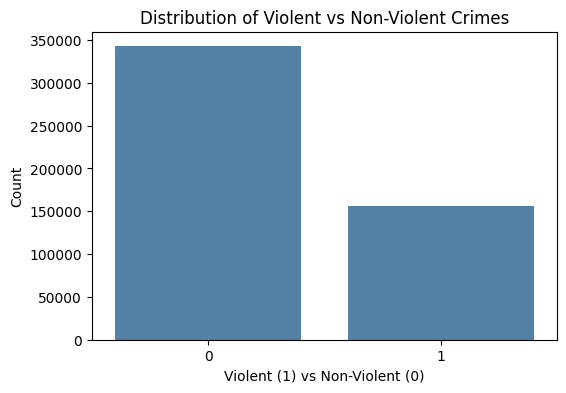

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

# Use the API: supply the dataframe and specify only x
# Use 'color' instead of 'palette' to avoid deprecation warnings
sns.countplot(data=data, x="violent", color="steelblue")

plt.title("Distribution of Violent vs Non-Violent Crimes")
plt.xlabel("Violent (1) vs Non-Violent (0)")
plt.ylabel("Count")

## Interpretation of Violent vs Non-Violent Crime Distribution

The chart shows a clear difference between the number of non-violent and
violent crimes. Non-violent crimes form the larger share of the dataset, which
is expected in most urban crime environments. Even though the classes are not
perfectly balanced, both categories contain a substantial number of records.
This allows the neural network to learn distinct patterns for both groups.

Understanding this distribution is important because it affects model
evaluation. When classes differ in size, accuracy alone may not fully reflect
the model’s performance, and additional metrics such as precision, recall, and
the confusion matrix become valuable during the validation phase.


# Top 15 Most Frequent Crime Categories

Understanding which crime categories occur most frequently helps provide
context for the overall dataset. The `primary_type` column contains the
high-level classification for each reported incident. Examining the most
common crime types offers insight into city-wide patterns and the general
composition of criminal activity.

This information is also helpful for feature interpretation. Even though the
neural network predicts whether a crime is violent or non-violent, the type
of crime often carries implicit contextual meaning, making it a relevant
attribute. The chart below highlights the top 15 crime categories based on
their frequency in the dataset.


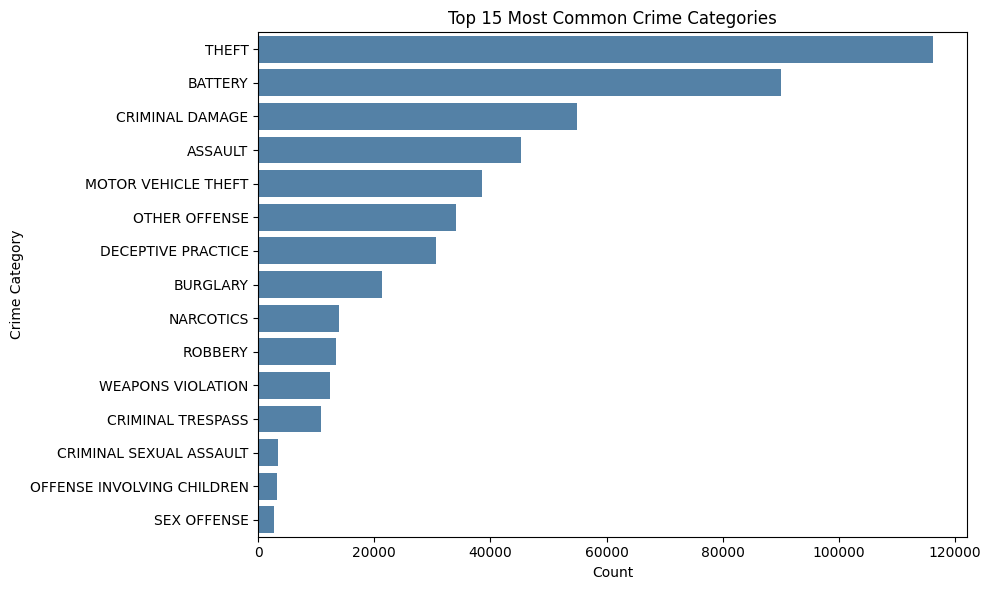

In [33]:
# Calculate top 15 crime categories
top_crimes = df["primary_type"].value_counts().head(15)

plt.figure(figsize=(10,6))

# Use barplot with 'color' to avoid Seaborn palette warnings
sns.barplot(x=top_crimes.values, y=top_crimes.index, color="steelblue")

plt.title("Top 15 Most Common Crime Categories")
plt.xlabel("Count")
plt.ylabel("Crime Category")

plt.tight_layout()
plt.show()

## Interpretation of Top Crime Categories

The chart highlights the most frequent crime categories in the dataset. Theft
is the most common incident by a wide margin, followed by battery and criminal
damage. Categories such as assault, motor vehicle theft, and deceptive
practice also appear frequently. These patterns reflect typical urban crime
distributions, where property-related crimes tend to dominate over violent
offenses.

Although the model’s objective is to classify incidents as violent or
non-violent, understanding the prevalence of different crime groups provides
helpful context. Some categories, such as assault, battery, robbery, and
criminal sexual assault, contribute directly to the violent crime class. Others
serve as strong indicators of non-violent behavior. This breakdown also
supports the feature engineering process by showing which categories may carry
more predictive influence in the neural network.


# Top 15 Most Common Crime Locations

The `location_description` field describes where each crime occurred. Examining
the most common locations provides insight into environmental patterns that may
influence crime behavior. Some locations, such as streets or residential areas,
naturally have higher incident counts due to population density and foot
traffic. Others represent more specific settings such as apartments, alleys, or
parking lots.

Understanding where crimes frequently occur helps highlight spatial context and
can provide additional support when interpreting the model’s behavior. The chart
below shows the top 15 crime locations based on their frequency.


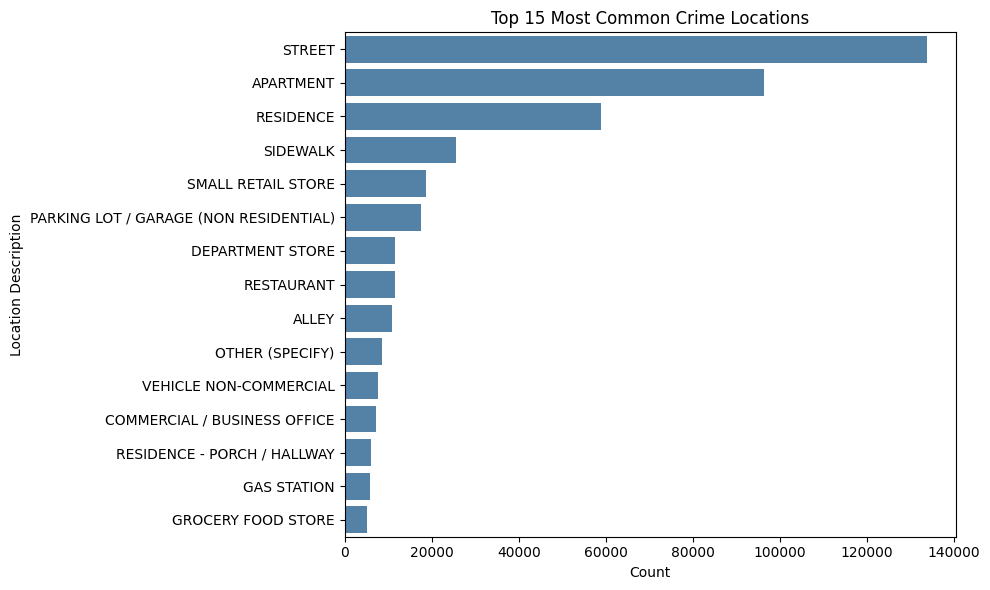

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute top 15 locations
top_locations = data["location_description"].value_counts().head(15)

plt.figure(figsize=(10,6))

# Use color instead of palette to avoid warnings
sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    color="steelblue"
)

plt.title("Top 15 Most Common Crime Locations")
plt.xlabel("Count")
plt.ylabel("Location Description")

plt.tight_layout()
plt.show()


## Interpretation of Crime Location Patterns

The chart shows that most reported incidents occur on streets, followed by
apartments and residential locations. Sidewalks and small retail stores also
contribute significantly to crime volume. These patterns reflect the typical
movement and gathering areas within a city, where both pedestrian activity and
residential density create more opportunities for incidents.

Locations toward the lower end of the list, such as parking garages, alleys,
restaurants, and business offices, occur with moderate frequency but still
represent meaningful environments for crime analysis. Understanding where
crimes most commonly occur provides a spatial context that contributes to the
feature set used by the neural network, especially when combined with
geographic coordinates and time-based indicators.


# Crime Frequency by Hour of the Day

Crime activity often follows recognizable daily patterns. Examining how crime
frequency varies by hour helps reveal whether incidents cluster around specific
times, such as late night, early morning, or evening hours. These patterns may
differ for violent and non-violent incidents, and understanding the general
distribution provides a strong basis for deeper temporal analysis.

The chart below shows the total number of crimes recorded for each hour of the
day. This helps highlight periods with increased activity and supports the
feature engineering process related to time-of-day variables.


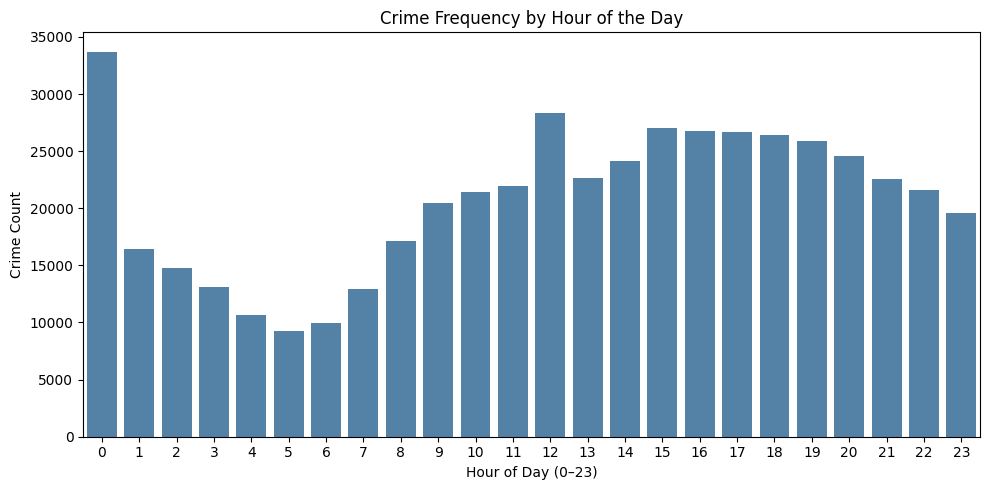

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate crimes per hour
hour_counts = data["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values,
    color="steelblue"
)

plt.title("Crime Frequency by Hour of the Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


## Interpretation of Crime Distribution by Hour of Day

The hourly distribution shows clear patterns in crime activity. Incidents peak
around midnight, followed by a sharp decline in the early morning hours. Crime
volume remains low between approximately 3 AM and 6 AM, which is consistent
with typical sleep cycles and reduced public activity.

As the day progresses, incident counts rise steadily, reaching another high
point around midday and continuing at elevated levels through the afternoon
and early evening. Activity remains strong until approximately 8 PM before
gradually decreasing into the night.

These temporal patterns suggest that time of day is an important contextual
feature for the neural network. The distinct shape of the distribution may
also indicate differing behavioral trends between violent and non-violent
crimes, which will be explored in later visualizations.


# Crime Frequency by Day of the Week

Weekly crime patterns often differ based on work schedules, nightlife
activity, and weekend behavior. Examining the distribution of incidents
across the days of the week helps reveal whether certain days consistently
show higher or lower activity.

The `day_of_week` variable encodes Monday as 0 and Sunday as 6. The chart
below displays how crime frequency varies across these seven categories.
Understanding this distribution provides additional insight into the temporal
structure of the dataset.


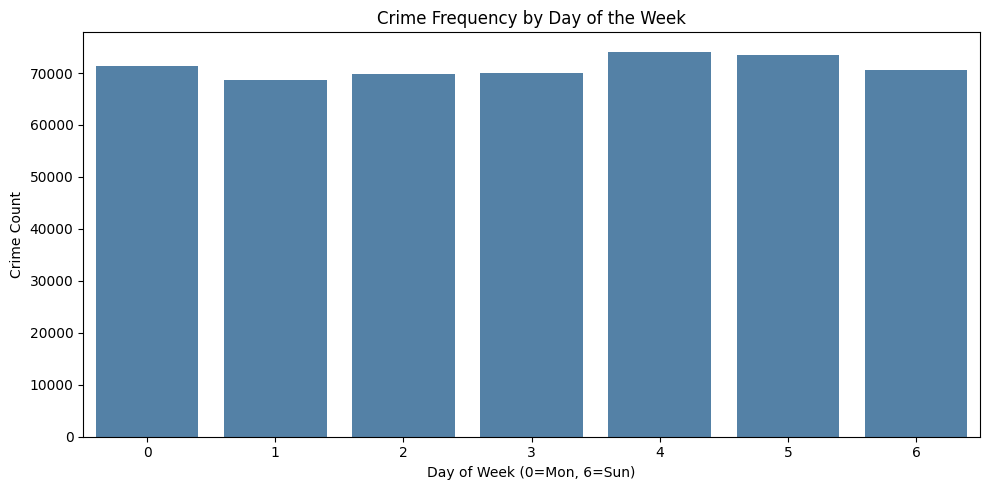

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate crimes per day of week
dow_counts = data["day_of_week"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_counts.index,
    y=dow_counts.values,
    color="steelblue"
)

plt.title("Crime Frequency by Day of the Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


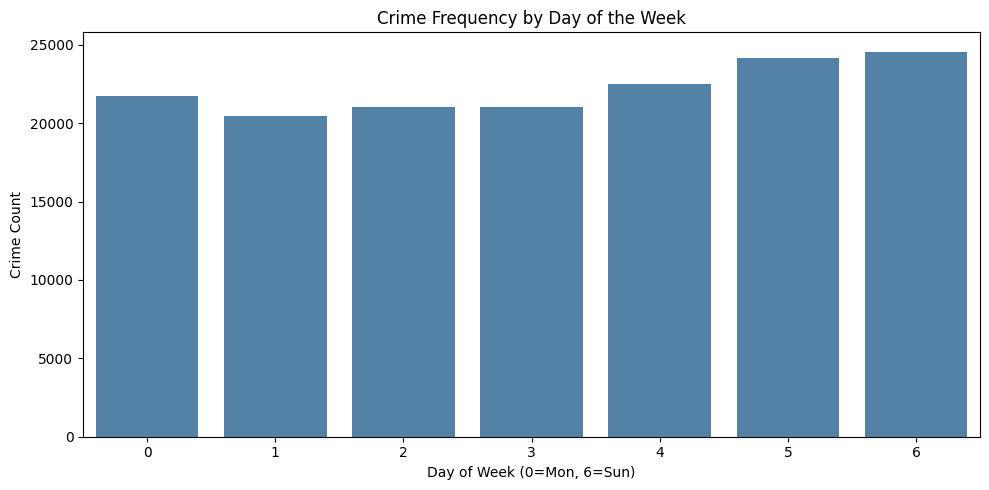

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate crimes per day of week
dow_counts = data[data["violent"]==1]["day_of_week"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_counts.index,
    y=dow_counts.values,
    color="steelblue"
)

plt.title("Crime Frequency by Day of the Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


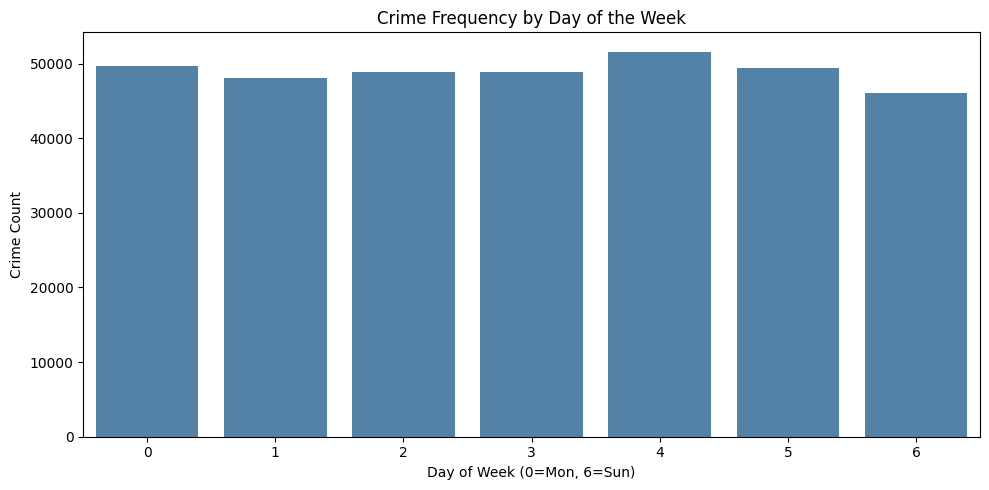

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate crimes per day of week
dow_counts = data[data["violent"]==0]["day_of_week"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_counts.index,
    y=dow_counts.values,
    color="steelblue"
)

plt.title("Crime Frequency by Day of the Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


## Interpretation of Crime Distribution by Day of the Week

The daily distribution shows that crime levels remain relatively consistent
across the week, with only slight variations between days. The number of
incidents tends to be slightly higher toward the middle and end of the week,
particularly around Thursday and Friday. Monday and Tuesday show marginally
lower activity, but the differences are not substantial.

This uniformity indicates that crime in the dataset is not strongly tied to
specific days of the week. Instead, the underlying patterns are likely driven
more by time of day, location, and crime type rather than weekday effects.
Still, including the day-of-week feature provides additional context that may
support the neural network’s ability to capture subtle temporal behaviors.


# Crime Frequency by Month

Seasonal trends can influence crime patterns due to changes in weather,
daylight hours, and social activity. Examining monthly crime totals helps
identify whether certain months consistently experience higher or lower levels
of criminal activity.

The `month` variable ranges from 1 to 12. The chart below shows the number of
incidents recorded in each month, allowing us to explore any seasonal
variations in the dataset.


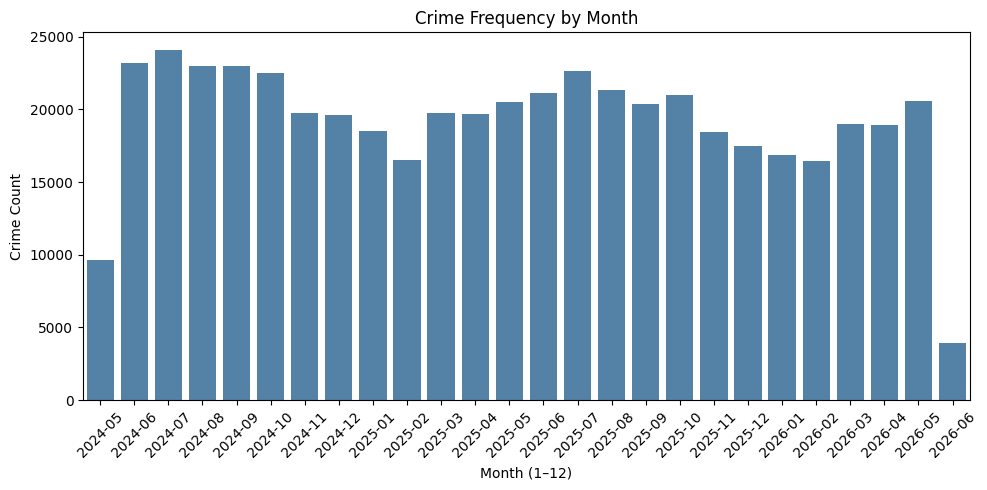

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count crimes by month
data["yr_mn"]=df["date"].apply(lambda x:x[0:7])
month_counts = data["yr_mn"].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    color="steelblue"
)

plt.title("Crime Frequency by Month")
plt.xlabel("Month (1–12)")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Interpretation of Crime Distribution by Month

The monthly distribution reveals a clear seasonal trend. Crime counts increase
from January onward, reaching their highest levels in the summer months. June,
July, and August show the greatest number of incidents, which aligns with
patterns observed in many cities where warmer weather increases outdoor
activity and public interaction.

A noticeable decline appears in November, which may be influenced by shorter
daylight hours, colder conditions, or incomplete data for the latest months
in the dataset. The overall pattern shows that seasonal factors play a
significant role in shaping crime activity, making the month feature an
important temporal input for the neural network.


# Violent vs Non-Violent Crimes by Hour of the Day

Comparing violent and non-violent incidents across the hours of the day helps
identify whether the two categories follow similar or different daily rhythms.
Certain types of violent crimes tend to occur more frequently during late-night
or early-morning hours, while non-violent crimes may align more with business
hours or daytime activity.

The chart below visualizes both distributions side by side, allowing us to
observe any notable contrasts in hourly patterns between the two groups.


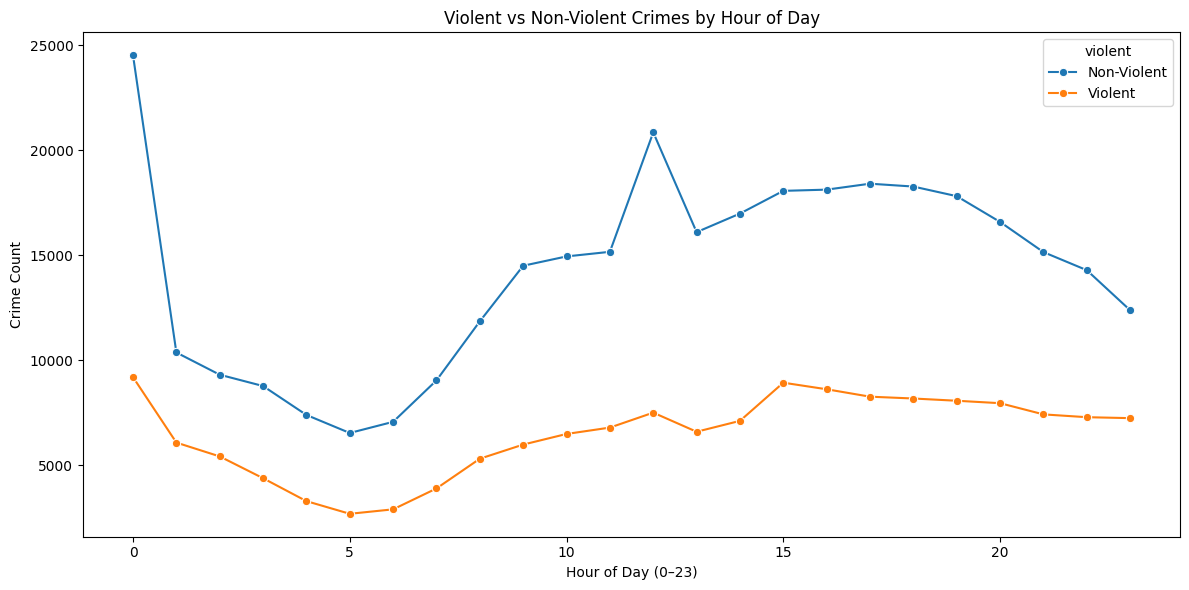

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Group by hour and violent status
hourly_violent = data.groupby(["hour", "violent"]).size().reset_index(name="count")

# Convert violent from numeric to label for clearer visualization
hourly_violent["violent"] = hourly_violent["violent"].map({0: "Non-Violent", 1: "Violent"})

sns.lineplot(
    data=hourly_violent,
    x="hour",
    y="count",
    hue="violent",
    marker="o"
)

plt.title("Violent vs Non-Violent Crimes by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


## Interpretation of Violent vs Non-Violent Crime by Hour of the Day

The comparison between violent and non-violent incidents reveals clear
differences in their hourly patterns. Non-violent crimes peak sharply around
midnight and then decline rapidly during the early morning hours. As the day
progresses, non-violent activity rises again, reaching consistently high levels
between late morning and early evening.

Violent crimes display a different rhythm. While they also show higher activity
around midnight, the decline in early morning hours is more gradual. Violent
incidents increase again during the afternoon and show noticeable peaks between
midday and evening hours.

The presence of distinct shapes in both lines suggests that violent and
non-violent crimes may be influenced by different behavioral or situational
factors. These differences support the use of temporal features as meaningful
inputs to the neural network model.


# Violent vs Non-Violent Crimes by Day of Week

This visualization compares the weekly distribution of violent and non-violent
incidents. While overall crime counts remain fairly consistent across the week,
violent crimes may follow slightly different patterns depending on social
activity, weekend behavior, or other environmental factors.

Plotting both trends side by side highlights whether violent crimes exhibit
any weekday-specific tendencies compared to non-violent crimes.


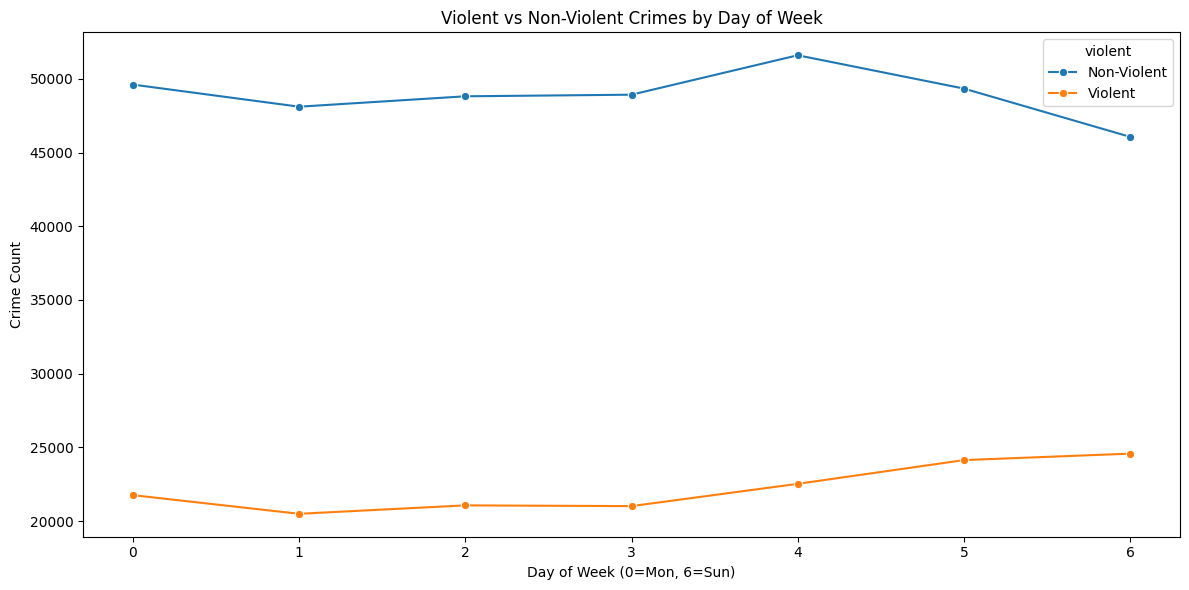

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Group by day_of_week and violent indicator
dow_violent = data.groupby(["day_of_week", "violent"]).size().reset_index(name="count")

# Map labels for clarity
dow_violent["violent"] = dow_violent["violent"].map({0: "Non-Violent", 1: "Violent"})

sns.lineplot(
    data=dow_violent,
    x="day_of_week",
    y="count",
    hue="violent",
    marker="o"
)

plt.title("Violent vs Non-Violent Crimes by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


# Spatial Distribution of Crimes (Latitude vs Longitude)

Geographic patterns are often central to crime analysis. Plotting incidents by
their latitude and longitude helps reveal areas with dense activity and visual
clusters. Although this scatterplot does not provide the precision of a full
geospatial heatmap, it offers a clear overview of how crimes are distributed
across the city.

Because the dataset contains a large number of records, a low transparency
(alpha) level is used to avoid overcrowding and to highlight dense regions
more effectively.


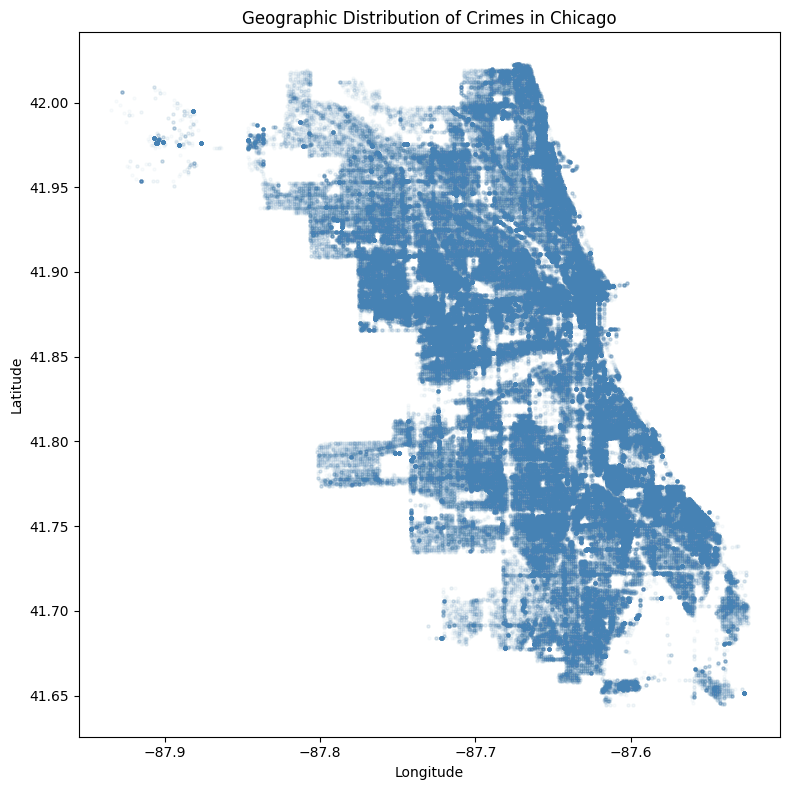

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Scatter plot with alpha for density visibility
plt.scatter(
    data["longitude"],
    data["latitude"],
    s=5,
    alpha=0.03,
    color="steelblue"
)

plt.title("Geographic Distribution of Crimes in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


## Interpretation of Geographic Crime Distribution

The scatter plot provides a clear visual outline of Chicago, formed entirely by
the geographic coordinates of crime incidents. Areas with higher point density
represent regions with more frequent activity. The dense clustering along the
central and southern regions of the map indicates concentrated crime zones,
while lighter areas represent regions with fewer incidents.

Even though this is not a full geospatial heatmap, the density patterns are
visible through the overlapping points. The distribution highlights the value
of latitude and longitude as predictive features, especially in a large urban
environment where crime levels vary significantly by neighborhood and district.


# Crime Count by Police District

Police districts represent administrative boundaries used in law enforcement.
Examining how many crimes are reported in each district helps reveal patterns
in workload, population density, and geographic clustering of incidents.

The chart below shows the number of crimes recorded in each district, allowing
us to compare activity levels across different administrative zones.


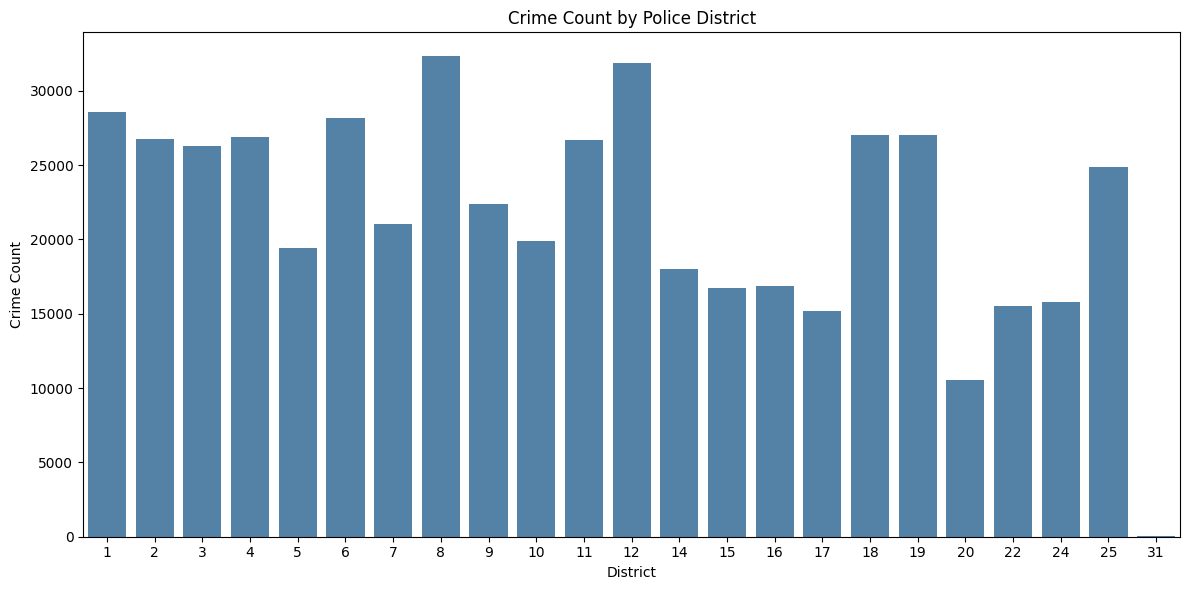

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count crimes by district
district_counts = data["district"].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x=district_counts.index,
    y=district_counts.values,
    color="steelblue"
)

plt.title("Crime Count by Police District")
plt.xlabel("District")
plt.ylabel("Crime Count")

plt.tight_layout()
plt.show()


## Interpretation of Crime Count by Police District

The chart shows significant variation in crime counts across different police
districts. Several districts record over 12,000 incidents, while others fall
well below 7,000 cases. These differences reflect a mixture of factors such as
population density, neighborhood characteristics, and enforcement activity.

Districts with higher volumes often correspond to areas with greater foot
traffic, commercial activity, or densely populated residential zones. Lower
volume districts typically represent regions with smaller populations or
reduced reporting frequency. Including district information in the model helps
the neural network capture spatial differences in crime patterns across the
city.


## Correlation Heatmap for Numeric Features

This heatmap provides an overview of how numeric variables relate to one
another. Strong correlations can indicate overlapping information, while weak
relationships suggest that features contribute independently to the model.

Visualizing these correlations helps reveal which spatial or temporal
attributes move together and supports decisions about model design and
feature selection. It also highlights why normalization and scaling are
important when working with neural networks.


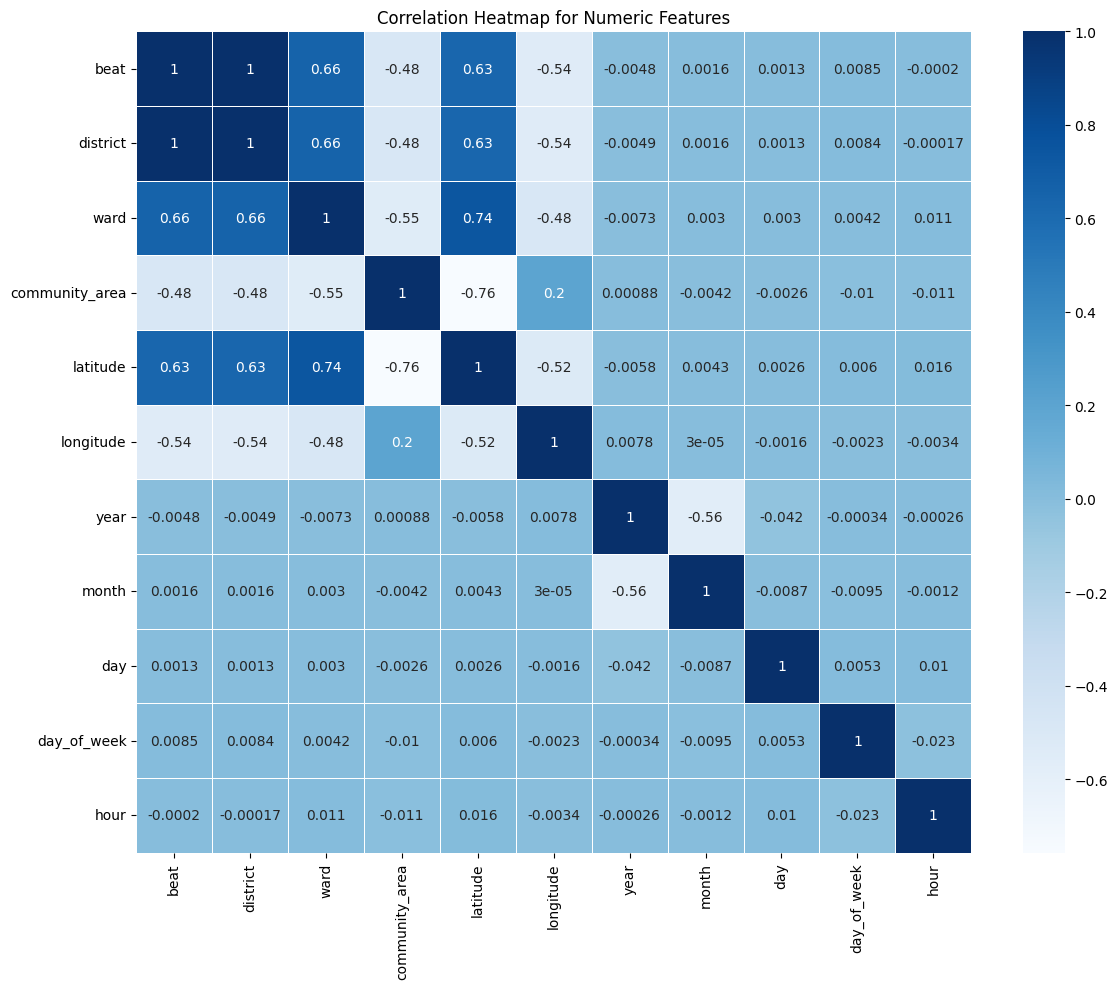

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_cols_for_corr = [
    "beat",
    "district",
    "ward",
    "community_area",
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "day_of_week",
    "hour"
]

numeric_data = data[numeric_cols_for_corr]

# Compute correlation matrix
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.show()


## Interpretation of the Correlation Heatmap

The heatmap reveals several strong relationships among the spatial features.
Latitude, longitude exhibit clear clusters of
high correlation, which is expected because they represent closely related
geographic measurements. Strong positive correlations within this group
indicate that these variables move together and collectively describe the
location of each incident.

The administrative geographical attributes such as district, ward, and beat
also show moderate correlations with one another. This reflects the hierarchical
structure of Chicago’s policing and administrative boundaries, where several
beats fall within a district and several districts overlap with ward and
community boundary lines.

Temporal features such as month, day, and hour show very weak correlations with
the spatial and administrative features, suggesting that time-based patterns are
generally independent of geographic location.

Overall, the correlation structure highlights two important points for model
building:
1. Spatial features contain significant shared information that the neural
   network will learn to leverage.
2. Temporal features contribute independently, allowing the model to capture
   nonlinear relationships without redundancy.

These observations support the use of a neural network, which is well suited to
model both strongly correlated and weakly related feature groups through
nonlinear transformations.


# Understanding Artificial Neural Networks for Crime Classification

Before building the neural network model, it is important to understand how an
artificial neuron processes information and why this structure is well suited
for classifying violent and non-violent crimes.

A neural network is composed of layers of interconnected units called neurons.
Each neuron receives several input features, multiplies them by weights,
applies a bias, and passes the result through a non-linear activation function.
This transformation allows the network to learn complex relationships between
the input variables and the target outcome.

For this project, the input features include spatial attributes, temporal
variables, administrative boundaries, and crime descriptions. These features
interact in highly non-linear ways, making neural networks a natural choice for
capturing patterns that simpler models may not fully detect.

The following sections explore how a single neuron computes its output, how
multiple neurons form layers, and how information flows from input to output
through forward propagation. Understanding these concepts provides a strong
foundation before moving into the implementation of the model.


# Mathematical Intuition Behind a Neuron

A neuron is the fundamental unit of an artificial neural network. It takes in
multiple inputs, applies weights to those inputs, adds a bias term, and then
passes the result through an activation function.

Each input feature contributes differently to the final output, depending on
its weight. During training, these weights are adjusted so that the network
learns how to make more accurate predictions.

For a single neuron receiving inputs \(x_1, x_2, x_3, ..., x_n\) with
corresponding weights \(w_1, w_2, w_3, ..., w_n\) and a bias term \(b\), the
neuron computes a weighted sum:

**Weighted Sum = (w₁×x₁) + (w₂×x₂) + … + (wₙ×xₙ) + b**

This weighted sum captures how strongly each input feature pushes the neuron
toward a particular output. The bias term helps shift the decision boundary,
allowing the model to fit patterns that do not pass through the origin.

After computing the weighted sum, the neuron applies an activation function,
which introduces non-linearity into the model. Without activation functions,
the entire neural network would behave like a simple linear model and fail to
capture the complex interactions present in real-world data such as crime
patterns in different locations and times of the day.


# Role of Activation Functions in Learning Patterns

Activation functions allow neural networks to learn non-linear relationships.
Real-world crime behavior is rarely linear: crime levels vary across spatial
zones, peak at specific hours, and depend on contextual features that interact
in complex ways.

Activation functions transform the weighted sum into a non-linear output. Some
commonly used activation functions include:

- ReLU: outputs zero for negative values and the raw input for positive values.
- Sigmoid: squeezes values between 0 and 1, useful for binary classification.
- Tanh: outputs values between -1 and 1, symmetric around zero.

For this project, ReLU will be used in the hidden layers because it helps the
network learn efficiently by avoiding saturation issues. The output layer will
use the sigmoid activation to generate a probability between 0 and 1, which is
well suited for predicting whether a crime is violent or non-violent.


# Forward Propagation: How Predictions Are Generated

Forward propagation is the process where input data flows through the network
to produce an output. It involves the following steps:

1. Each input feature (such as hour, district, latitude, or crime type) is
   multiplied by its corresponding weight.

2. The weighted sum is computed and passed through an activation function in
   the hidden layers.

3. The transformed output from each layer becomes the input to the next layer.

4. The final layer produces a probability value between 0 and 1 through the
   sigmoid activation function, indicating how likely the incident is to be a
   violent crime.

Forward propagation allows the model to combine spatial, temporal, and
contextual features to estimate risk levels. As features interact across
layers, the network learns increasingly abstract representations, improving
its ability to distinguish violent from non-violent incidents.


# Loss Function and Cost Minimization

To train the neural network, the model’s predictions need to be compared with
the actual labels. The difference between predicted and true values is measured
using a loss function.

For binary classification tasks, the Binary Cross-Entropy loss is appropriate.
It penalizes confident but incorrect predictions more heavily than uncertain
ones, which helps guide the model toward better decision boundaries.

Once the loss is computed, an optimization algorithm such as gradient descent
adjusts the weights and biases. This process continues iteratively across many
epochs. With each update, the model reduces its overall loss, improving its
ability to classify new incidents accurately.

The combination of forward propagation, loss computation, and weight updates
during training enables the network to learn from data and generalize to unseen
cases.


# Designing the Neural Network Architecture

With the data prepared and the theoretical foundations established, the next
step is to design the structure of the Artificial Neural Network. The goal is
to create a model capable of learning patterns from a mixture of spatial,
temporal, administrative, and categorical features.

The input layer receives the processed feature matrix, which in our case has
several hundred input dimensions due to one-hot encoding of categorical
variables. Each neuron in the input layer represents one feature.

The hidden layers transform these inputs through multiple weighted
connections. Increasing the number of neurons allows the model to learn richer,
more abstract representations of the data. However, adding too many layers or
neurons can lead to overfitting. The architecture should balance model
complexity and generalization.

For this project:
- ReLU activation will be used in hidden layers because it helps the model
  learn efficiently and avoid saturation.
- Dropout will be added to reduce overfitting by randomly disabling neurons
  during training.
- The output layer will use a single neuron with a sigmoid activation function
  to produce a probability between 0 and 1, indicating whether an incident is
  violent or non-violent.

This architecture leverages non-linear transformations, making it suitable for
capturing interactions between different feature groups such as location,
crime type, and time of day.


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [46]:
input_dim = X_train.shape[1]
print(input_dim)

476


In [47]:
model = Sequential()
model.add(Input(shape=(input_dim,))) #Input Layer

model.add(Dense(128, activation="relu")) #Hidden Layer
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu")) #Hidden Layer
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid")) #Output Layer

In [48]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        61,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,377 (271.00 KB)

 Trainable params: 69,377 (271.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
458*128+128

58752

## Interpretation of the Neural Network Architecture

The model consists of two hidden layers followed by a single output layer. The
first dense layer contains 128 neurons and uses the ReLU activation function.
This layer transforms the high-dimensional input features into a richer
representation. Dropout is applied immediately after this layer to reduce the
risk of overfitting by temporarily disabling a portion of the neurons during
training.

The second dense layer contains 64 neurons, again using the ReLU activation
function, followed by another dropout layer. This structure allows the network
to learn progressively more abstract combinations of spatial, temporal, and
categorical patterns.

The output layer contains a single neuron with a sigmoid activation function.
This produces a probability between 0 and 1, representing the likelihood that
the incident is a violent crime.

The model summary shows a total of 67k+ trainable parameters, indicating that
the network has enough capacity to learn complex relationships but is not so
large that it becomes difficult to train or prone to excessive overfitting.


# Training the Neural Network Model

The model is now ready to be trained using the processed training dataset.
During training, the network adjusts its weights and biases so that the loss
function decreases over time. Early stopping is used to monitor the validation
loss and prevent the model from overfitting by stopping training once the
performance stops improving.

A portion of the training data is set aside as a validation set. This allows
the network’s performance to be evaluated on data it does not directly learn
from during each epoch. The training history recorded here will later be used
to visualize the learning curves for loss and accuracy.


In [51]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 97s 76ms/step - accuracy: 0.9832 - loss: 0.0430 - val_accuracy: 0.9983 - val_loss: 0.0089
Epoch 2/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9982 - loss: 0.0091 - val_accuracy: 0.9984 - val_loss: 0.0080
Epoch 3/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9982 - loss: 0.0088 - val_accuracy: 0.9983 - val_loss: 0.0076
Epoch 4/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9983 - loss: 0.0084 - val_accuracy: 0.9984 - val_loss: 0.0076
Epoch 5/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9983 - loss: 0.0083 - val_accuracy: 0.9984 - val_loss: 0.0077
Epoch 6/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9983 - loss: 0.0082 - val_accuracy: 0.9984 - val_loss: 0.0075
Epoch 7/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 0.9984 - val_loss: 0.0075
Epoch 8/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9983 - loss: 0.00

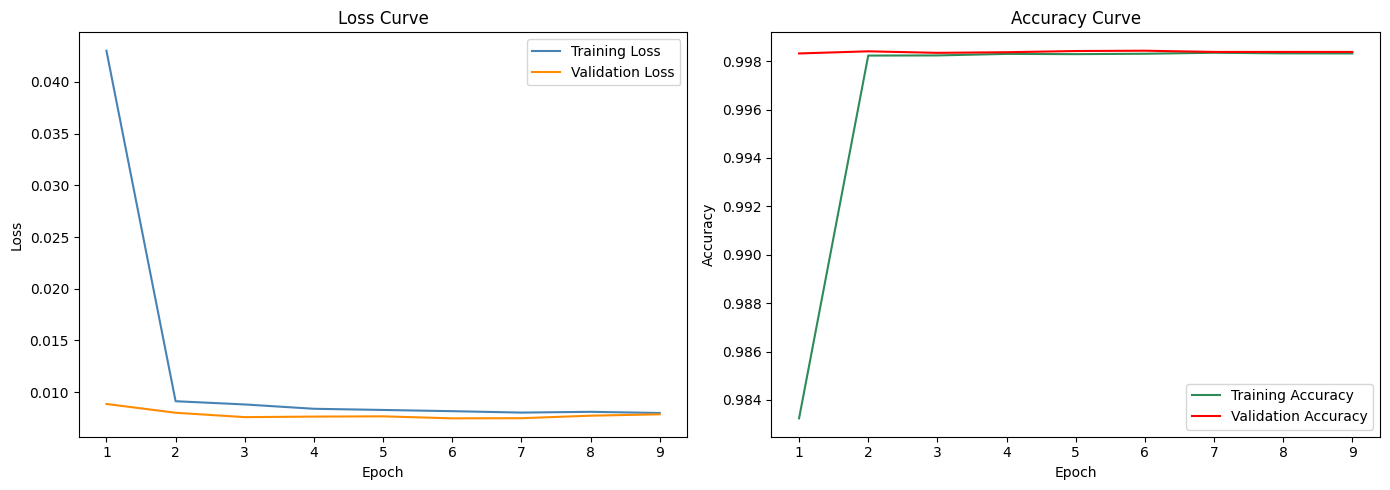

In [52]:
import matplotlib.pyplot as plt

# Extract metrics
loss = history.history["loss"]
val_loss = history.history.get("val_loss")
accuracy = history.history["accuracy"]
val_accuracy = history.history.get("val_accuracy")

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(14,5))

# ----------------------
# Plot Loss
# ----------------------
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label="Training Loss", color="steelblue")
if val_loss is not None:
    plt.plot(epochs, val_loss, label="Validation Loss", color="darkorange")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# ----------------------
# Plot Accuracy
# ----------------------
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, label="Training Accuracy", color="seagreen")
if val_accuracy is not None:
    plt.plot(epochs, val_accuracy, label="Validation Accuracy", color="red")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [53]:
data.columns

Index(['description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'year', 'latitude', 'longitude',
       'violent', 'month', 'day', 'day_of_week', 'hour', 'yr_mn'],
      dtype='object')

In [54]:
data.description.unique()

array(['THEFT FROM MOTOR VEHICLE', 'SIMPLE',
       'BURGLARY FROM MOTOR VEHICLE', 'AUTOMOBILE', 'TO PROPERTY',
       'COMPUTER FRAUD', 'ILLEGAL USE CASH CARD', '$500 AND UNDER',
       'DOMESTIC BATTERY SIMPLE', 'TO VEHICLE', 'POCKET-PICKING',
       'OVER $500', 'RETAIL THEFT', 'CREDIT CARD FRAUD', 'NON-AGGRAVATED',
       'AGGRAVATED - HANDGUN', 'UNLAWFUL USE - HANDGUN', 'TO RESIDENCE',
       'AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY',
       'FROM BUILDING', 'UNLAWFUL POSSESSION - HANDGUN',
       'LICENSE VIOLATION', 'TO LAND', 'ARMED - HANDGUN',
       'FALSE / STOLEN / ALTERED TRP',
       'GUN OFFENDER - ANNUAL REGISTRATION',
       'AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY',
       'AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON',
       'OTHER WEAPONS VIOLATION', 'POSSESS - COCAINE',
       'AGGRAVATED - KNIFE / CUTTING INSTRUMENT', 'ARMED - OTHER FIREARM',
       'ARMED - KNIFE / CUTTING INSTRUMENT', 'BY FIRE',
       'AGGRAVATED DOME

In [55]:
# Remove leakage columns
leakage_cols = ["description"]
# Updated categorical features (keep only non-leaking categorical columns)
categorical_cols = [
    "location_description"
]

# Updated numeric features
numeric_cols = [
    "beat",
    "district",
    "ward",
    "community_area",
    "latitude",
    "longitude",
    "month",
    "day",
    "day_of_week",
    "hour"
]

# Binary features
binary_cols = ["arrest", "domestic"]

# Target
target_col = "violent"

# Construct new feature matrix
X = data[categorical_cols + numeric_cols + binary_cols]
y = data[target_col]

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [58]:
X_train.shape

(398409, 146)

In [59]:
input_dim=X_train.shape[1]
print(input_dim)

146


In [60]:
model = Sequential()
model.add(Input(shape=(input_dim,))) #Input Layer

model.add(Dense(128, activation="relu")) #Hidden Layer
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu")) #Hidden Layer
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

In [61]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [62]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 109s 86ms/step - accuracy: 0.7586 - loss: 0.5266 - val_accuracy: 0.7699 - val_loss: 0.5057
Epoch 2/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7697 - loss: 0.5101 - val_accuracy: 0.7714 - val_loss: 0.5032
Epoch 3/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7707 - loss: 0.5073 - val_accuracy: 0.7720 - val_loss: 0.5018
Epoch 4/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7717 - loss: 0.5054 - val_accuracy: 0.7720 - val_loss: 0.5011
Epoch 5/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7721 - loss: 0.5041 - val_accuracy: 0.7728 - val_loss: 0.5005
Epoch 6/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7723 - loss: 0.5032 - val_accuracy: 0.7729 - val_loss: 0.5005
Epoch 7/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7724 - loss: 0.5024 - val_accuracy: 0.7734 - val_loss: 0.4989
Epoch 8/25
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7731 - loss: 0.501

3113/3113 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step


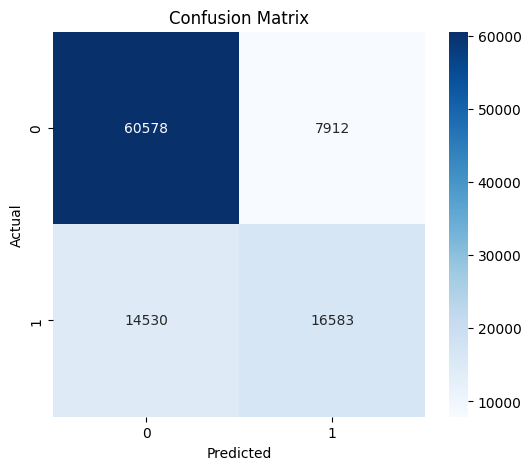

              precision    recall  f1-score   support

           0       0.81      0.88      0.84     68490
           1       0.68      0.53      0.60     31113

    accuracy                           0.77     99603
   macro avg       0.74      0.71      0.72     99603
weighted avg       0.77      0.77      0.77     99603



In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))
